# Estudio Comparativo de Solucionadores para el Oscilador Armónico Subamortiguado: De Métodos Clásicos a PINNs

### 1. Introducción
El presente cuaderno constituye el seguimiento técnico del Trabajo de Fin de Grado centrado en la resolución de **Ecuaciones Diferenciales Ordinarias (EDO)** mediante arquitecturas de Aprendizaje Profundo. El sistema físico de estudio es el **Oscilador Armónico Subamortiguado**.

### 2. Fundamentos Matemáticos
La dinámica del sistema viene regida por la EDO de segundo orden:

$$\frac{d^2x}{dt^2} + 2\gamma\frac{dx}{dt} + \omega_0^2x = 0$$

Donde:
* $\omega_0$: Frecuencia angular natural del sistema.
* $\gamma$: Coeficiente de amortiguamiento ($\gamma < \omega_0$ para el caso subamortiguado).
* $x(0) = x_0, \dot{x}(0) = v_0$: Condiciones iniciales de posición y velocidad.

La solución analítica exacta contra la que compararemos nuestros modelos es:
$$x(t) = e^{-\gamma t} \left( x_0 \cos(\omega_d t) + \frac{v_0 + \gamma x_0}{\omega_d} \sin(\omega_d t) \right)$$
Donde $\omega_d = \sqrt{\omega_0^2 - \gamma^2}$ es la frecuencia amortiguada.



### 3. Objetivos del Seguimiento
Evaluamos y contrastamos tres paradigmas de computación científica bajo una arquitectura común de **3 capas ocultas con 50 neuronas** cada una:

1. **Método Numérico Clásico (RK4):** Implementación de Runge-Kutta de 4.º.
2. **Aprendizaje Basado en Datos (Data-Driven):** Entrenamiento de un Perceptrón Multicapa (MLP) convencional que "aprende" la curva a partir de etiquetas, respecto a su dependencia de datos previos.
3. **Physics-Informed Neural Networks (PINNs):** Aplicación de una red neuronal en **PyTorch** que integra la EDO directamente en su función de pérdida mediante diferenciación automática, permitiendo resolver el sistema sin necesidad de datos de entrenamiento, únicamente respetando las leyes físicas.

# Configuración de Parámetros Globales

Se establece una parametrización unificada para el sistema dinámico del oscilador armónico subamortiguado con el fin de garantizar la consistencia metodológica y asegurar que la evaluación del error sea atribuible exclusivamente a las propiedades intrínsecas de cada algoritmo de resolución.

#### Parámetros del Oscilador Armónico Subamortiguado

| Parámetro | Símbolo | Valor | Unidades | Definición Técnica |
| :--- | :---: | :---: | :---: | :--- |
| **Frecuencia Natural** | $\omega_0$ | $1.0$ | $\text{rad/s}$ | Frecuencia de oscilación del sistema sin amortiguamiento. |
| **Amortiguamiento** | $\gamma$ | $0.1$ | $\text{s}^{-1}$ | Coeficiente que rige la disipación de energía. |
| **Frecuencia Amortiguada**| $\omega_d$ | $0.99$ | $\text{rad/s}$ | Frecuencia calculada como $\sqrt{\omega_0^2 - \gamma^2}$. |
| **Posición Inicial** | $x_0$ | $1.0$ | $\text{m}$ | Condición de contorno para el desplazamiento en $t = 0$. |
| **Velocidad Inicial** | $v_0$ | $0.0$ | $\text{m/s}$ | Condición de contorno para la velocidad en $t = 0$. |
| **Horizonte Temporal** | $t_{max}$ | $20.0$ | $\text{s}$ | Tiempo total de observación de la dinámica. |

# Solución Analítica
Para validar los resultados representamos la solución analítica exacta para los parámetros escogidos.

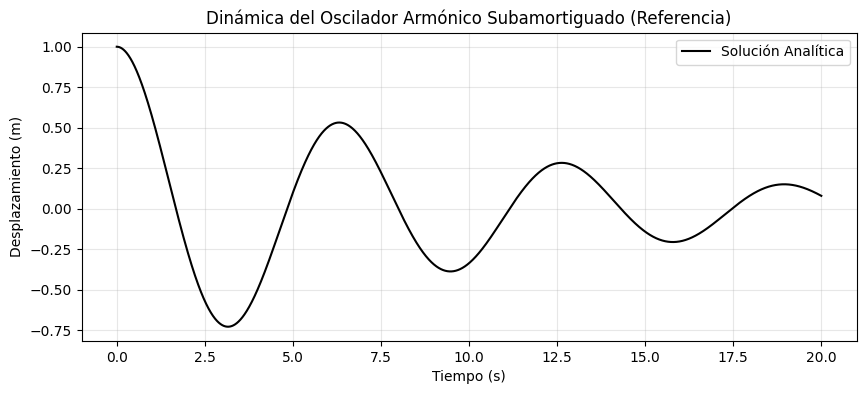

In [11]:
import numpy as np
import matplotlib.pyplot as plt
omega0 = 1.0
gamma = 0.1
x0 = 1.0
v0 = 0.0
t_eval = np.linspace(0, 20, 4000)
wd = np.sqrt(omega0**2 - gamma**2)
x_analitica = np.exp(-gamma * t_eval) * (
    x0 * np.cos(wd * t_eval) + 
    ((v0 + gamma * x0) / wd) * np.sin(wd * t_eval)
)
plt.figure(figsize=(10, 4))
plt.plot(t_eval, x_analitica, label="Solución Analítica", color='black', lw=1.5)
plt.title("Dinámica del Oscilador Armónico Subamortiguado (Referencia)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Desplazamiento (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Metodo numérico Clásico (RK4)

Este es un método iterativo de paso a paso que discretiza el dominio temporal y utiliza una combinación ponderada de cuatro pendientes dentro de cada intervalo ($h$) para aproximar el siguiente estado del sistema.
Para aplicar RK4, transformamos nuestra EDO de segundo orden en un sistema de dos ecuaciones de primer orden:

1.  $\frac{dx}{dt} = v$
2.  $\frac{dv}{dt} = -2\gamma v - \omega_0^2 x$

Error L2 absoluto: 5.094651024582184e-11
Error L2 relativo: 3.183679174701643e-11
Tiempo de ejecución: 0.13950586318969727 segundos


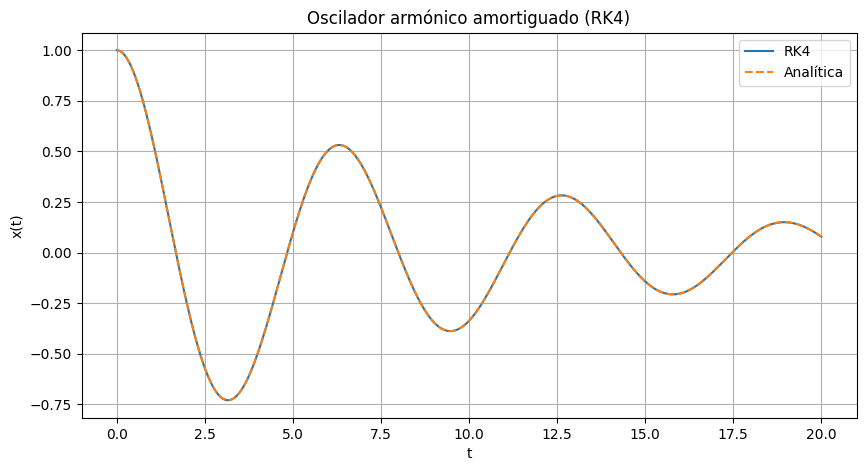

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time
#tiempo de ejecución INICIO
start_time = time.time()
# Parámetros
omega0 = 1.0
gamma  = 0.1
x0 = 1.0
v0 = 0.0
# Tiempo
t0, tf = 0.0, 20.0
N = 4000
t = np.linspace(t0, tf, N+1)
h = t[1] - t[0]
# Sistema 1er orden
def f(t, y):
    x, v = y
    dxdt = v
    dvdt = -2*gamma*v - omega0**2 * x
    return np.array([dxdt, dvdt])
# runge-kutta 4
y = np.zeros((N+1, 2))
y[0] = [x0, v0]
for i in range(N):
    k1 = f(t[i],         y[i])
    k2 = f(t[i] + h/2.0, y[i] + h*k1/2.0)
    k3 = f(t[i] + h/2.0, y[i] + h*k2/2.0)
    k4 = f(t[i] + h,     y[i] + h*k3)
    y[i+1] = y[i] + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

x = y[:, 0]

# Solución analítica (subamortiguado)
wd = np.sqrt(max(omega0**2 - gamma**2, 0.0))
x_analitica = np.exp(-gamma*t) * (x0*np.cos(wd*t) + (v0 + gamma*x0)/wd*np.sin(wd*t))
# Error L2
err_L2 = np.sqrt(np.sum((x - x_analitica)**2) * h)
rel_L2 = err_L2 / (np.sqrt(np.sum(x_analitica**2)*h) + 1e-30)
print("Error L2 absoluto:", err_L2)
print("Error L2 relativo:", rel_L2)
#tiempo de ejecución FINAL
end_time = time.time()
print("Tiempo de ejecución:", end_time - start_time, "segundos")
# Gráfica de resultados
plt.figure(figsize=(10,5))
plt.plot(t, x, label="RK4")
plt.plot(t, x_analitica, "--", label="Analítica")
plt.title("Oscilador armónico amortiguado (RK4)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.legend()
plt.show()

# Red Neuronal (MLP o multilayer perceptrons )

El segundo enfoque consiste en el uso de una **Red Neuronal Artificial (ANN)** convencional. En este paradigma, el modelo actúa como un **aproximador universal de funciones** que aprende la dinámica del sistema mediante un proceso de regresión supervisada.

Debido al carácter oscilatorio y sinusoidal del problema, se han seleccionado funciones de activación de tipo tangente hiperbólica ($\tanh$) en lugar de la clásica función sigmoidal.

Tanto en esta red como en la red PINNs se utilizará la siguiente estructura:

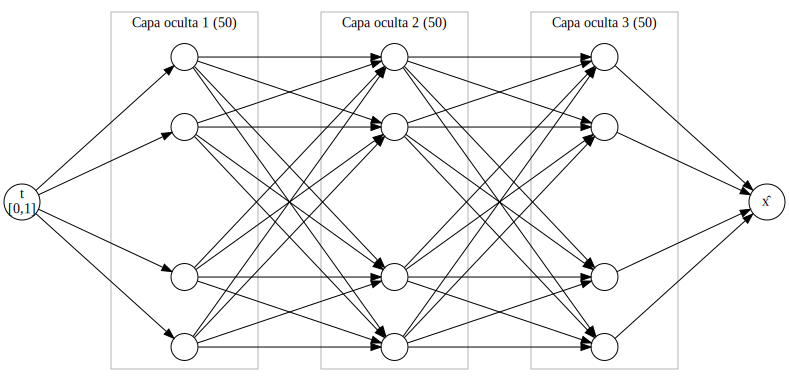

In [13]:
from graphviz import Digraph

def add_compressed_layer(dot, name, total_neurons, label):
    """
    Capa comprimida: 1 neurona arriba, ⋮, 2 neuronas abajo.
    Devuelve lista de neuronas representativas (sin los puntos).
    """
    with dot.subgraph(name=f"cluster_{name}") as c:
        c.attr(label=f"{label} ({total_neurons})", color="gray70")
        c.attr("node", shape="circle", fixedsize="true", width="0.38")

        top = f"{name}_top"
        mid = f"{name}_mid"
        dots = f"{name}_dots"
        bot1 = f"{name}_bot1"
        bot2 = f"{name}_bot2"

        c.node(top, "")
        c.node(mid, "")
        c.node(dots, "⋮", shape="plaintext")
        c.node(bot1, "")
        c.node(bot2, "")

        # Para que queden en columna (rank=same dentro del cluster ayuda, pero esto lo refuerza)
        c.attr(rankdir="TB")

    return [top, mid, bot1, bot2]


def fully_connect(dot, left_nodes, right_nodes, **edge_attrs):
    """Conecta todas las neuronas representativas de izquierda a derecha."""
    for a in left_nodes:
        for b in right_nodes:
            dot.edge(a, b, **edge_attrs)


dot = Digraph("PINN_FC_3x50", format="png")
dot.attr(rankdir="LR", splines="line", nodesep="0.6", ranksep="1.1")  # splines=line => rectas
dot.attr("edge", penwidth="1")  # grosor estándar

# Entrada: t (tiempo normalizado)
dot.node("t", "t\n[0,1]", shape="circle", fixedsize="true", width="0.5")

# Capas ocultas: 3x50
H1 = add_compressed_layer(dot, "H1", 50, "Capa oculta 1")
H2 = add_compressed_layer(dot, "H2", 50, "Capa oculta 2")
H3 = add_compressed_layer(dot, "H3", 50, "Capa oculta 3")

# Salida: x_hat (desplazamiento predicho)
dot.node("xhat", "x̂", shape="circle", fixedsize="true", width="0.5")

# Conexiones: “denso” representado con conexiones completas entre nodos representativos
# Entrada -> H1 (conecta t a todas las representativas de H1)
for n in H1:
    dot.edge("t", n)

# H1 -> H2, H2 -> H3, H3 -> Salida
fully_connect(dot, H1, H2)
fully_connect(dot, H2, H3)

for n in H3:
    dot.edge(n, "xhat")

dot

Para el desarrollo del código en el enfoque basado en datos, se han implementado dos metodologías distintas con el fin de contrastar la eficiencia y la complejidad de programación:

1. **Implementación (NumPy):** programo desde cero  el algoritmo de **descenso de gradiente** siguiendo la estructura de Michael Nielsen. Esto implica la resolución manual de la regla de la cadena para el *backward pass* a través de las 3 capas ocultas, permitiendo un control total sobre la actualización de pesos y sesgos.
   
2. **Implementación (PyTorch):** Se hace uso del motor de diferenciación automática (**Autograd**) mediante el modelo `RedOscilator`. En este caso, se emplea el optimizador **Adam** (*Adaptive Moment Estimation*), que destaca por su capacidad de ajustar dinámicamente la tasa de aprendizaje, superando las limitaciones del descenso de gradiente básico. Se puede apliacar refinamiento mediante otros optimizadores como L-BFGS.

## Implementación Numpy

Epoch 0, Error: 0.13398769634687593
Epoch 1000, Error: 0.06890514376084617
Epoch 2000, Error: 0.030991220340752756
Epoch 3000, Error: 0.024747745711663435
Epoch 4000, Error: 0.013405573233549115
Epoch 5000, Error: 0.01150287737531324
Epoch 6000, Error: 0.007842663830097496
Epoch 7000, Error: 0.012618917671634021
Epoch 8000, Error: 0.005823290191328031
Epoch 9000, Error: 0.0068695877801956216
Epoch 10000, Error: 0.003592505835359513
Epoch 11000, Error: 0.0010828777679534874
Epoch 12000, Error: 0.0008892738165625046
Epoch 13000, Error: 0.0009957520162557684
Epoch 14000, Error: 0.000795952918413743
Epoch 15000, Error: 0.0007185931570720388
Epoch 16000, Error: 0.000879760054803457
Epoch 17000, Error: 0.0007620141187768672
Epoch 18000, Error: 0.0006358006192197134
Epoch 19000, Error: 0.0005714318830421834
Epoch 20000, Error: 0.0005819406141919782
Epoch 21000, Error: 0.0007552340508069751
Epoch 22000, Error: 0.0006597785381455797
Epoch 23000, Error: 0.0007653709668490141
Epoch 24000, Error: 

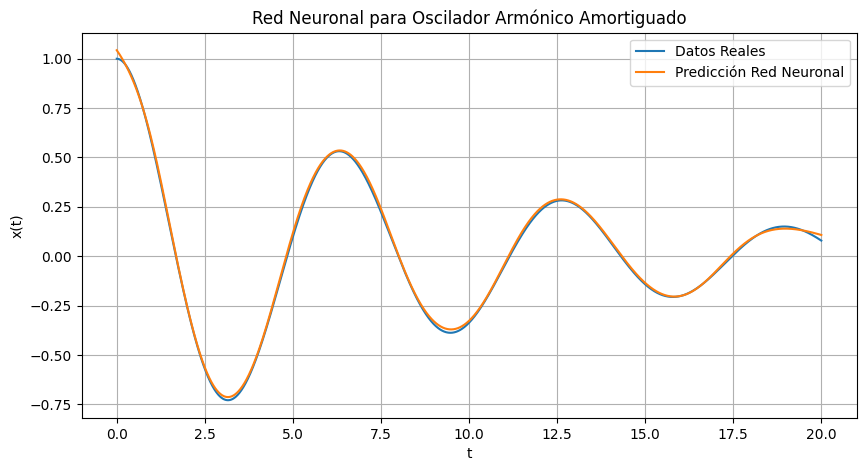

In [14]:
import numpy as np
import matplotlib.pyplot as plt 
# Parámetros
omega0 = 1.0
gamma  = 0.1
x0 = 1.0
v0 = 0.0
# Tiempo
t0, tf = 0.0, 20.0
N = 4000
t = np.linspace(t0, tf, N)
#solución analítica (subamortiguado)
wd = np.sqrt(max(omega0**2 - gamma**2, 0.0))
x_analitica = np.exp(-gamma*t) * (x0*np.cos(wd*t) + (v0 + gamma*x0)/wd*np.sin(wd*t))
#Vamos a normalizar los datos para que estén entre 0 y 1
X= t.reshape(-1,1)/np.max(t)
y = x_analitica.reshape(-1,1)
#Vamos a crear una red neuronal con tres capas ocultas de 50 neuronas, 1 capa de entrada y una capa de salida
np.random.seed(42)
#Pesos de la capa de entrada a la primera capa oculta
W1 = np.random.randn(1,50)*np.sqrt(1/1)
b1 = np.zeros((1,50))
#Pesos de la primera capa oculta a la segunda capa oculta
W2 = np.random.randn(50,50)*np.sqrt(1/50)
b2 = np.zeros((1,50))
#Pesos de la segunda capa oculta a la capa de salida
W3 = np.random.randn(50,50)*np.sqrt(1/50)
b3 = np.zeros((1,50))
#Pesos de la tercera capa oculta a la capa de salida
W4 = np.random.randn(50,1)*np.sqrt(1/50)
b4 = np.zeros((1,1))
#Función de activación tangente hiperbólica (evitamos la sigmoide al no reflejar valores negativos)
def tanh(x):
    return np.tanh(x)
def tanh_derivada(x):
    return 1.0 - np.tanh(x)**2
#Bucle de entrenamiento
learning_rate = 0.15
epochs = 100000
for epoch in range(epochs):
    #Forward pass (adelante)
    z1 = X.dot(W1) + b1
    a1 = tanh(z1)
    z2 = a1.dot(W2) + b2
    a2 = tanh(z2)
    z3 = a2.dot(W3) + b3
    a3 = tanh(z3)
    z4 = a3.dot(W4) + b4
    y_pred = z4
    #Cálculo del error (MSE)
    error = np.mean((y_pred - y)**2)
    #Backward pass (retropropagación)
    derror_dypred = 2*(y_pred - y)/y.shape[0]
    dypred_dz4 = 1
    dz4_da3 = W4
    da3_dz3 = tanh_derivada(z3)
    dz3_da2 = W3
    da2_dz2 = tanh_derivada(z2)
    dz2_da1 = W2
    da1_dz1 = tanh_derivada(z1)
    dz1_dW1 = X
    #Gradientes para la capa de salida
    derror_dz4 = derror_dypred * dypred_dz4
    derror_dW4 = a3.T.dot(derror_dz4)
    derror_db4 = np.sum(derror_dz4, axis=0, keepdims=True)
    #Gradientes para la tercera capa oculta
    derror_da3 = derror_dz4.dot(dz4_da3.T)
    derror_dz3 = derror_da3 * da3_dz3
    derror_dW3 = a2.T.dot(derror_dz3)
    derror_db3 = np.sum(derror_dz3, axis=0, keepdims=True)
    #Gradientes para la segunda capa oculta
    derror_da2 = derror_dz3.dot(dz3_da2.T)
    derror_dz2 = derror_da2 * da2_dz2
    derror_dW2 = a1.T.dot(derror_dz2)
    derror_db2 = np.sum(derror_dz2, axis=0, keepdims=True)
    #Gradientes para la primera capa oculta
    derror_da1 = derror_dz2.dot(dz2_da1.T)
    derror_dz1 = derror_da1 * da1_dz1
    derror_dW1 = X.T.dot(derror_dz1)
    derror_db1 = np.sum(derror_dz1, axis=0, keepdims=True)
    #Actualización de pesos y sesgos
    W4 -= learning_rate * derror_dW4
    b4 -= learning_rate * derror_db4
    W3 -= learning_rate * derror_dW3
    b3 -= learning_rate * derror_db3
    W2 -= learning_rate * derror_dW2
    b2 -= learning_rate * derror_db2
    W1 -= learning_rate * derror_dW1
    b1 -= learning_rate * derror_db1
    #Imprimir el error cada 1000 épocas
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Error: {error}")
#Predicción final
z1 = X.dot(W1) + b1
a1 = tanh(z1)
z2 = a1.dot(W2) + b2
a2 = tanh(z2)
z3 = a2.dot(W3) + b3  
a3 = tanh(z3)
z4 = a3.dot(W4) + b4
y_pred = z4
#guardar configuración de pesos y sesgos
np.savez("red_neuronal_osc_amortiguado.npz", W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3, W4=W4, b4=b4)
#error relativo L2 entre la predicción y los datos reales
error_relativo = np.linalg.norm(y_pred - y) / np.linalg.norm(y)
print(f"Error relativo L2: {error_relativo:.6f}")
#error MAE entre la predicción y los datos reales
error_mae = np.mean(np.abs(y_pred - y))
print(f"Error MAE: {error_mae:.6f}")
#Gráfica de resultados
plt.figure(figsize=(10,5))
plt.plot(t, y, label="Datos Reales")
plt.plot(t, y_pred, label="Predicción Red Neuronal")   
plt.title("Red Neuronal para Oscilador Armónico Amortiguado")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.legend()
plt.show()

## Implementación Pytorch

Epoch 0, Loss: 0.12967829
Epoch 2000, Loss: 0.00073578
Epoch 4000, Loss: 0.00034153
Epoch 6000, Loss: 0.00002383
Epoch 8000, Loss: 0.00001110
Epoch 10000, Loss: 0.00000761
Epoch 12000, Loss: 0.00000534
Epoch 14000, Loss: 0.00000379
Epoch 16000, Loss: 0.00000266
Epoch 18000, Loss: 0.00000195
Epoch 20000, Loss: 0.00000258
Epoch 22000, Loss: 0.00001729
Epoch 24000, Loss: 0.00000088
Epoch 26000, Loss: 0.00002640
Epoch 28000, Loss: 0.00003886
Epoch 30000, Loss: 0.00000116
Epoch 32000, Loss: 0.00000065
Epoch 34000, Loss: 0.00000228
Epoch 36000, Loss: 0.00000058
Epoch 38000, Loss: 0.00000053
Epoch 40000, Loss: 0.00000068
Epoch 42000, Loss: 0.00000055
Epoch 44000, Loss: 0.00000084
Epoch 46000, Loss: 0.00000423
Epoch 48000, Loss: 0.00000207

Tiempo de entrenamiento: 427.38 segundos

Error relativo L2: 0.001602
Error MAE: 0.000359


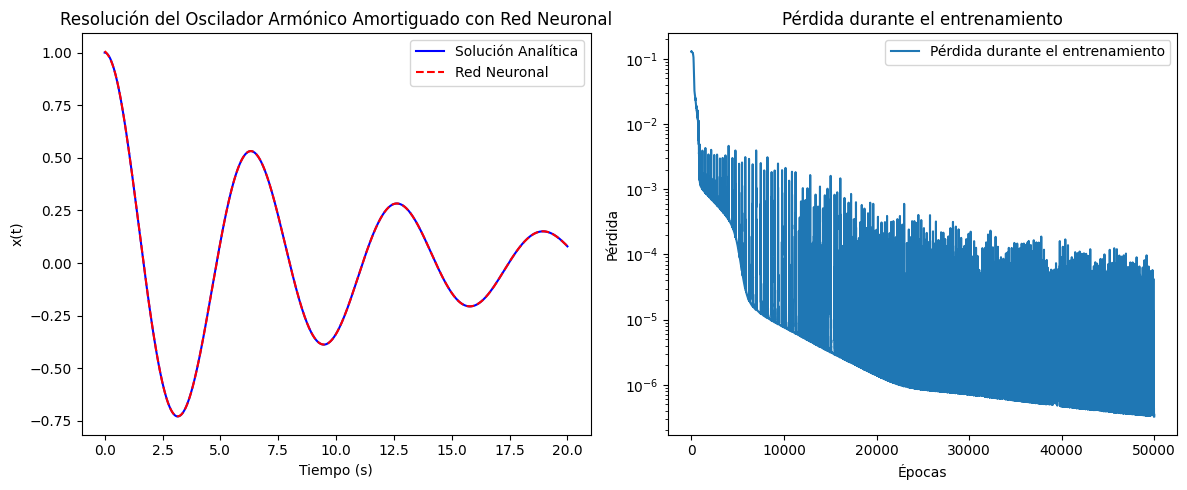

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
time_start = time.time()
# 1. Parámetros
omega0, gamma, x0, v0 = 1.0, 0.1, 1.0, 0.0
t0, tf, N = 0.0, 20.0, 4000

t_np = np.linspace(t0, tf, N)
wd = np.sqrt(max(omega0**2 - gamma**2, 0.0))
x_ana_np = np.exp(-gamma*t_np) * (x0*np.cos(wd*t_np) + (v0 + gamma*x0)/wd*np.sin(wd*t_np))

X = torch.tensor(t_np.reshape(-1, 1) / tf, dtype=torch.float32)
y = torch.tensor(x_ana_np.reshape(-1, 1), dtype=torch.float32)

# Arquitectura de la Red (segimos la misma que en la versión básica)
class RedOscilador(nn.Module):
    def __init__(self):
        super(RedOscilador, self).__init__()
        self.net = nn.Sequential(nn.Linear(1, 50),nn.Tanh(),nn.Linear(50, 50),nn.Tanh(),nn.Linear(50, 50),nn.Tanh(),nn.Linear(50, 1))
        
    def forward(self, x):
        return self.net(x)

# Seed y modelo
torch.manual_seed(42)
model = RedOscilador()
# Usamos el optimizador Adam y la función de pérdida MSE
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
epochs = 50000 
loss_history = []
for epoch in range(epochs):
    optimizer.zero_grad()
    # Forward pass
    y_pred = model(X)
    # Calcular pérdida
    loss = criterion(y_pred, y)
    # Backward pass
    loss.backward()
    # Actualizamos los pesos
    optimizer.step()
    loss_history.append(loss.item())
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.8f}")
time_end = time.time()
print(f"\nTiempo de entrenamiento: {time_end - time_start:.2f} segundos")
# Evaluamos el modelo 
model.eval()
with torch.no_grad():
    y_final = model(X)
# Error relativo L2
error_l2 = torch.norm(y_final - y) / torch.norm(y)
# Error MAE
error_mae = torch.mean(torch.abs(y_final - y))

print(f"\nError relativo L2: {error_l2.item():.6f}")
print(f"Error MAE: {error_mae.item():.6f}")
#guardamos pesos, sesgos, perdidas, errores, tiempo de entrenamiento
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss_history': loss_history,
    'error_l2': error_l2.item(),
    'error_mae': error_mae.item(),
    'training_time': time_end - time_start
}, 'red_oscilador.pth')
#graficamos solución y errores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_np, x_ana_np, label='Solución Analítica', color='blue')
plt.plot(t_np, y_final.numpy(), label='Red Neuronal', color='red', linestyle='dashed')
plt.title('Resolución del Oscilador Armónico Amortiguado con Red Neuronal')
plt.xlabel('Tiempo (s)')
plt.ylabel('x(t)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(loss_history, label='Pérdida durante el entrenamiento')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()


A diferencia del método manual, PyTorch logra capturar con precisión  tanto las oscilaciones de gran amplitud al inicio ($t < 5$) como las señales amortiguadas de baja amplitud al final del intervalo ($t \approx 20$).

# Red Neuronal PINNs

### Redes Neuronales Informadas por la Física (PINNs)
####  Definición de la Función de Pérdida Multiobjetivo
La red es evaluada a través de una función de pérdida compuesta por tres componentes críticos, lo que garantiza que la solución sea matemáticamente única y físicamente coherente:

1.  **Residuo de la EDO ($\mathcal{L}_{f}$):** Evalúa si la predicción cumple la ecuación del oscilador ($\hat{x}'' + 2\gamma \hat{x}' + \omega_0^2 \hat{x} = 0$) en los 4,000 puntos de colocación distribuidos en el dominio temporal.
2.  **Condición de Contorno de Posición ($\mathcal{L}_{u}$):** Penaliza a la red si en el instante $t=0$ el valor predicho no coincide estrictamente con el desplazamiento inicial $x_0$.
3.  **Condición de Contorno de Velocidad ($\mathcal{L}_{v}$):** Asegura que la derivada temporal en el origen coincida con $v_0$ (en este caso, reposo), definiendo así la fase correcta de la oscilación.



####  Diferenciación Automática de Orden Superior
Para la construcción de este modelo, se ha utilizado el motor **Autograd** de PyTorch. Esta herramienta permite calcular las derivadas de la salida respecto a la entrada (tiempo) de forma analítica y exacta mediante la regla de la cadena, evitando los errores de truncamiento de las diferencias finitas:
* **Velocidad ($\dot{x}$):** Primera derivada obtenida mediante `torch.autograd.grad`.
* **Aceleración ($\ddot{x}$):** Segunda derivada calculada sobre el grafo de computación de la primera (`create_graph=True`), permitiendo una resolución continua del sistema.



#### Especificaciones de la Arquitectura y Entrenamiento
Se mantiene la homogeneidad estructural para permitir una comparativa justa entre los paradigmas evaluados:
* **Estructura:** 1 entrada (t), 3 capas ocultas de 50 neuronas y 1 salida (x).
* **Activación:** Función tangente hiperbólica ($\tanh$) para garantizar la existencia y suavidad de las derivadas de segundo orden.
* **Optimización:** Algoritmo **Adam** ($lr=0.001$) ejecutado durante 50,000 épocas.
* **Métricas de Control:** Se monitoriza el **Error Relativo $L^2$** y la **Varianza de la pérdida** en las últimas 100 épocas para certificar la estabilidad de la convergencia.

Epoch 0, Loss: 1.082445
Epoch 1000, Loss: 0.006289
Epoch 2000, Loss: 0.004365
Epoch 3000, Loss: 0.003821
Epoch 4000, Loss: 0.003530
Epoch 5000, Loss: 0.003298
Epoch 6000, Loss: 0.003034
Epoch 7000, Loss: 0.002830
Epoch 8000, Loss: 0.002492
Epoch 9000, Loss: 0.002327
Epoch 10000, Loss: 0.002327
Epoch 11000, Loss: 0.002222
Epoch 12000, Loss: 0.002186
Epoch 13000, Loss: 0.002193
Epoch 14000, Loss: 0.001679
Epoch 15000, Loss: 0.001595
Epoch 16000, Loss: 0.001448
Epoch 17000, Loss: 0.001387
Epoch 18000, Loss: 0.001958
Epoch 19000, Loss: 0.001149
Epoch 20000, Loss: 0.000601
Epoch 21000, Loss: 0.000602
Epoch 22000, Loss: 0.000538
Epoch 23000, Loss: 0.000504
Epoch 24000, Loss: 0.000453
Epoch 25000, Loss: 0.000357
Epoch 26000, Loss: 0.001392
Epoch 27000, Loss: 0.000098
Epoch 28000, Loss: 0.000056
Epoch 29000, Loss: 0.000040
Epoch 30000, Loss: 0.000046
Epoch 31000, Loss: 0.000067
Epoch 32000, Loss: 0.000111
Epoch 33000, Loss: 0.000023
Epoch 34000, Loss: 0.000026
Epoch 35000, Loss: 0.000434
Epoch

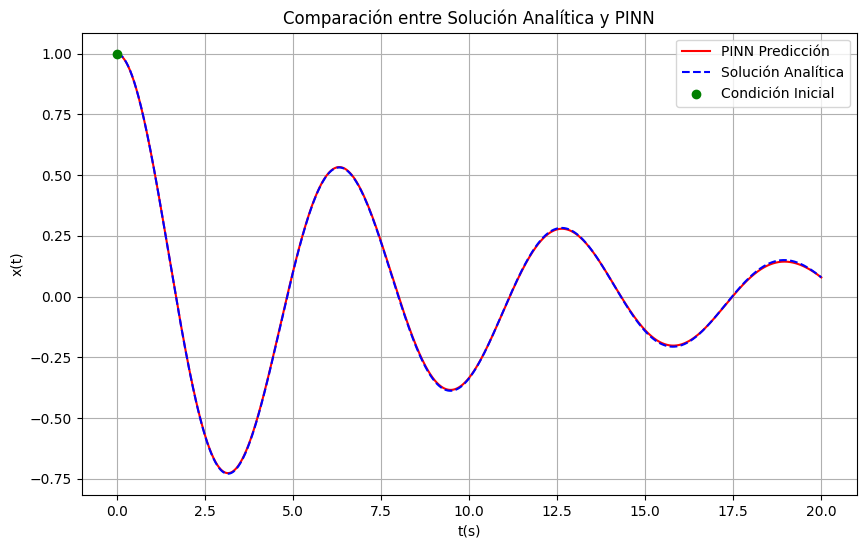

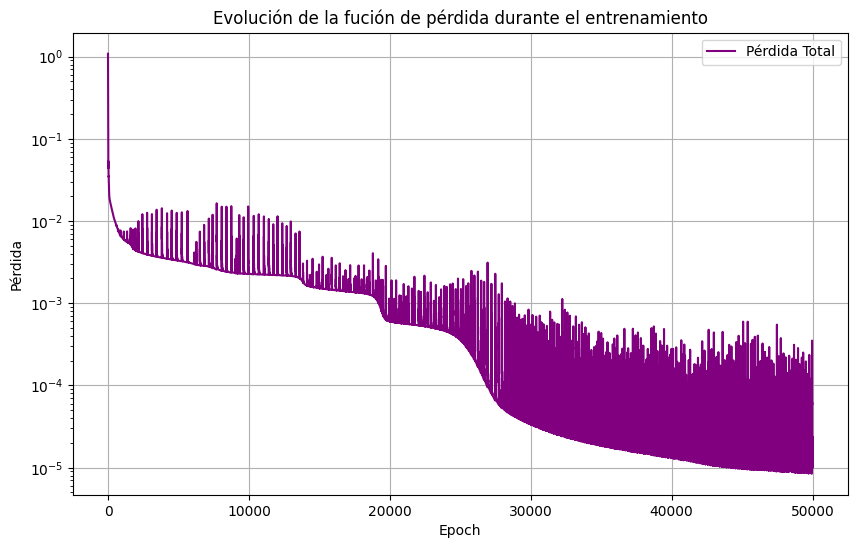

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
#ecuación ocilador armonico subamortiguado#
def oscilador_armonico_subamortiguado(t, omega0, gamma):
    assert gamma < omega0, "El sistema no es subamortiguado"
    omega = np.sqrt(omega0**2 - gamma**2)
    fase = np.arctan(gamma/omega)
    A = 1/(2*np.cos(fase))
    x = A*torch.exp(-gamma*t)*torch.cos(omega*t-fase)
    return x
#RED NEURONAL#
class PINN(nn.Module):
    def __init__(self,N_input,N_oculta,N_output,N_capas):
        super().__init__()
        self.funcion_activacion = nn.Tanh()
        self.capa_input = nn.Sequential(nn.Linear(N_input,N_oculta), self.funcion_activacion)
        self.capa_oculta = nn.Sequential(*[nn.Sequential(nn.Linear(N_oculta,N_oculta), self.funcion_activacion) for _ in range(N_capas-1)])
        self.capa_output = nn.Linear(N_oculta,N_output)
    
    def forward(self,x):
        x = self.capa_input(x)
        x = self.capa_oculta(x)
        return self.capa_output(x)

#Puntos para el modelo PINN temporales#
t = torch.linspace(0, 20, 4000).reshape(-1, 1).requires_grad_(True)
#fijamos la seed para la reproducibilidad
torch.manual_seed(42)
#Inicializamos la red neuronal
model = PINN(N_input=1, N_oculta=50, N_output=1, N_capas=3)
#Definimos el optimizador# #Recordar probar en Adam y SGD para comparar resultados#
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_values = []
#Entrenamiento#
omega0 = 1.0
gamma = 0.1
x0 = 1.0
v0 = 0.0
import time; start_time = time.time()
for epoch in range(50000):
    optimizer.zero_grad()
    #Predicción de la red neuronal#
    x_pred = model(t)
    # Primera derivada (velocidad)
    dx_dt = torch.autograd.grad(x_pred, t, grad_outputs=torch.ones_like(x_pred), create_graph=True)[0]
    
    # Segunda derivada (aceleración)
    d2x_dt2 = torch.autograd.grad(dx_dt, t, grad_outputs=torch.ones_like(dx_dt), create_graph=True)[0]  
    #Definimos la función de pérdida#
    f = d2x_dt2 + 2*gamma*dx_dt + omega0**2*x_pred
    loss_f = torch.mean(f**2)
    # Condición inicial x(0) = x0
    x_0_pred = model(torch.tensor([[0.0]]))
    loss_u = torch.mean((x_0_pred - x0)**2)
    # Condición de velocidad inicial v(0) = 0
    t0 = torch.tensor([[0.0]], requires_grad=True)
    x0_val = model(t0)
    v0_val = torch.autograd.grad(x0_val, t0, create_graph=True)[0]
    loss_v = torch.mean((v0_val - v0)**2)
    # Pérdida total con pesos para cada término
    loss = loss_u + loss_f + loss_v
    loss_values.append(loss.item())
    loss.backward()
    optimizer.step()    
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}')

#calculo de norma L2
error_relativo_L2=torch.sqrt(torch.mean((x_pred - oscilador_armonico_subamortiguado(t, omega0, gamma))**2)) / torch.sqrt(torch.mean(oscilador_armonico_subamortiguado(t, omega0, gamma)**2))
print(f"Error relativo L2: {error_relativo_L2.item():.6f}")
#error absoluto medio MAE
error_absoluto_medio_MAE=torch.mean(torch.abs(x_pred - oscilador_armonico_subamortiguado(t, omega0, gamma)))
print(f"Error absoluto medio MAE: {error_absoluto_medio_MAE.item():.6f}")
#estabilidad del método
estabilidad_final = np.var(loss_values[-100:])
print(f"Estabilidad del método (varianza de la pérdida en las últimas 100 épocas): {estabilidad_final:.6e}")
print(f"Tiempo de cálculo: {time.time() - start_time:.2f} segundos")
#Resultados#
x_pred = model(t).detach().numpy()
t = t.detach().numpy()
plt.figure(figsize=(10, 6))
plt.plot(t, x_pred, label='PINN Predicción', color='red')
#guardamos datos 
np.savez("pinn_oscilador_amortiguado_PINNs.npz", t=t, x_pred=x_pred, error_absoluto_medio_MAE=error_absoluto_medio_MAE.item(), error_relativo_L2=error_relativo_L2.item(), estabilidad_final=estabilidad_final, loss_values=loss_values)
# Solución analítica para comparación
wd = np.sqrt(max(omega0**2 - gamma**2, 0.0))
t_analitica = np.linspace(0, 20, 1000)
x_analitica = np.exp(-gamma*t_analitica)*(x0*np.cos(wd*t_analitica)+(v0+gamma*x0)/wd*np.sin(wd*t_analitica))
plt.plot(t_analitica, x_analitica, label='Solución Analítica', color='blue', linestyle='dashed')
plt.scatter(0, x0, color='green', label='Condición Inicial', zorder=5) 
plt.title('Comparación entre Solución Analítica y PINN')
plt.xlabel('t(s)')
plt.ylabel('x(t)')
plt.legend()
plt.grid()
#grafica de la función de pérdida#
plt.figure(figsize=(10, 6))
plt.plot(loss_values, label='Pérdida Total', color='purple')
plt.title('Evolución de la fución de pérdida durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Pérdida')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()


# Inferencia del campo de presión mediante PINNs usando el dataset *Cylinder2D*

## 1. Carga y preparación del conjunto de datos

En este apartado se cargan los datos del conjunto **Cylinder2D**, utilizado en el trabajo de **Hidden Fluid Mechanics (HFM)**. Este conjunto contiene simulaciones de flujo alrededor de un cilindro resolviendo las ecuaciones de Navier-Stokes.

El archivo `.mat` contiene los siguientes campos:

- **U_star**: componente horizontal de la velocidad $u(x,y,t)$
- **V_star**: componente vertical de la velocidad $v(x,y,t)$
- **P_star**: campo de presión $p(x,y,t)$
- **x_star, y_star**: coordenadas espaciales
- **t_star**: coordenada temporal

Las dimensiones del dataset son:

- $N = 30189$ puntos espaciales
- $N_t = 201$ instantes temporales

Para trabajar con el dataset se reconstruye la malla espacio-temporal completa mediante operaciones de *tiling* y posteriormente se **aplanan los arrays** para generar un conjunto de observaciones de la forma

$$
(x, y, t, u, v, p)
$$

Esto permite tratar cada punto como una observación independiente del campo fluido.

Posteriormente se selecciona un **subdominio espacial**:

$$
1 \le x \le 8, \quad -2 \le y \le 2
$$

y un rango temporal

$$
t \le 7
$$

con el objetivo de reducir el tamaño del conjunto de datos y centrar el entrenamiento en la región de interés.

Finalmente se seleccionan **7000 puntos aleatorios** del dominio para utilizarlos como observaciones experimentales en el entrenamiento de la PINN.

Estas observaciones se utilizan únicamente para las componentes de velocidad $u,v$, mientras que la presión se inferirá mediante las ecuaciones físicas.

---

# 2. Definición del dominio físico

El flujo se modela en un dominio rectangular que representa una **sección idealizada de una arteria o conducto**, (tambén estoy planteando utilizar un dominio de disco al ser en 2D)

El dominio espacial es

$$
x \in [1,L], \quad y \in [-R,R]
$$

donde

- $L = 8$ cm es la longitud del conducto
- $R = 2$ cm es el radio

El dominio temporal es

$$
t \in [0,T]
$$

con

$$
T = 7\ \text{s}
$$

Este dominio se define en DeepXDE mediante la construcción de una **geometría espacio-tiempo**

$$
\Omega \times [0,T]
$$

lo que permite entrenar la red neuronal directamente sobre la solución dependiente del tiempo.

---

# 3. Ecuaciones físicas: Navier-Stokes incomprensible

El comportamiento del fluido está gobernado por las ecuaciones de Navier-Stokes para un fluido incomprensible en dos dimensiones.

### Ecuación de continuidad

$$
\frac{\partial u}{\partial x} +
\frac{\partial v}{\partial y} = 0
$$

### Conservación de momento

Componente $x$

$$
\rho \left(
\frac{\partial u}{\partial t}
+ u\frac{\partial u}{\partial x}
+ v\frac{\partial u}{\partial y}
\right)
=
-\frac{\partial p}{\partial x}
+
\mu \left(
\frac{\partial^2 u}{\partial x^2}
+
\frac{\partial^2 u}{\partial y^2}
\right)
$$

Componente $y$

$$
\rho \left(
\frac{\partial v}{\partial t}
+ u\frac{\partial v}{\partial x}
+ v\frac{\partial v}{\partial y}
\right)
=
-\frac{\partial p}{\partial y}
+
\mu \left(
\frac{\partial^2 v}{\partial x^2}
+
\frac{\partial^2 v}{\partial y^2}
\right)
$$

En el modelo se introducen dos **parámetros entrenables**:

- $C_1 = \rho$ densidad del fluido
- $C_2 = \mu$ viscosidad dinámica

Esto permite realizar **identificación de parámetros físicos** durante el entrenamiento de la PINN.

Los valores iniciales utilizados son

$$
\rho = 1.0 \ \text{g/cm}^3
$$

$$
\mu = 0.004 \ \text{Pa·s}
$$

A fecha actual todavia no consigo que se ajusten bien los resultados, $$\mu$$ ronda valores muy bajos o negativos, estoy provando en definirlo en escala logaritmica para evitar valores negativos pero solo es una suposición.
---

# 4. Condiciones de frontera e iniciales

Se imponen varias condiciones físicas para garantizar una solución bien definida.

## Condición en las paredes

En las paredes superior e inferior del conducto se impone la condición de **no deslizamiento**

$$
u = 0, \quad v = 0
$$
---

## Entrada del conducto

En la entrada se fija

$$
v = 0
$$

lo que implica que el flujo entra predominantemente en dirección axial.

---

## Salida del conducto

En la salida se fija la presión

$$
p = 0
$$

lo que equivale a una condición de referencia para el campo de presión.

---

## Condición inicial

Se supone que el fluido está inicialmente en reposo

$$
u(x,y,0) = 0
$$

$$
v(x,y,0) = 0
$$

---

# 5. Incorporación de datos experimentales

Además de las ecuaciones físicas, el entrenamiento utiliza **observaciones reales del campo de velocidad** en especifico del paquete de  de [**Hidden Fluid Mechanics**](https://github.com/maziarraissi/HFM)

Se introducen como condiciones

$$
u(x_i,y_i,t_i) = u_{data}
$$

$$
v(x_i,y_i,t_i) = v_{data}
$$

para los puntos seleccionados del dataset.

Se observan únicamente las velocidades y se reconstruye el campo de presión.

---

# 6. Arquitectura de la red neuronal

La red neuronal utilizada es un **Fully Connected Neural Network (FNN)**.

Arquitectura:

Entrada

$$
(x,y,t)
$$

Capas ocultas

3 capas con 64 neuronas cada una

Función de activación

$$
\tanh
$$

Salida

$$
(u,v,p)
$$

Los pesos se inicializan mediante el método **Glorot normal**.

---

# 7. Entrenamiento del modelo

El entrenamiento se realiza mediante el optimizador **Adam** con tasa de aprendizaje

$$
10^{-3}
$$

durante **20000 épocas**.

La función de pérdida combina:

- residuo de las ecuaciones de Navier-Stokes
- condiciones de frontera
- condiciones iniciales
- observaciones de velocidad

En paralelo estoy probando la aplicación de refinamiento despues del entrenamiento con el modelo L-BFGS 

---

# 8. Evaluación del modelo

Una vez entrenado el modelo, se comparan las predicciones con los datos observados.

Se calculan:

### Error relativo $L^2$

$$
\frac{||u_{pred}-u||_2}{||u||_2}
$$

$$
\frac{||v_{pred}-v||_2}{||v||_2}
$$

$$
\frac{||p_{pred}-p||_2}{||p||_2}
$$

### Error absoluto medio de la presión

$$
MAE =
\frac{1}{N}\sum |p_{pred}-p|
$$
---

# 9. Visualización de los resultados

Para analizar la solución obtenida se generan mapas de contorno de:

- velocidad horizontal $u(x,y,t)$
- velocidad vertical $v(x,y,t)$
- presión $p(x,y,t)$

para un instante temporal fijo.

Las predicciones se calculan sobre una malla regular en el dominio espacial.



In [1]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Carga de datos he copiado la carga del paquete del script de github, el formato de los datos es el mismo que el del script original.
data_mat = loadmat("TFG/DATA_HFM/Cylinder2D.mat")

U_star = data_mat["U_star"]  # (30189, 201)
V_star = data_mat["V_star"]  # (30189, 201)
P_star = data_mat["P_star"]  # (30189, 201)
t_star = data_mat["t_star"]  # (201, 1)
X_star = data_mat["x_star"]  # (30189, 1)
Y_star = data_mat["y_star"]  # (30189, 1)

N = X_star.shape[0]   # 30189
Nt = t_star.shape[0]  # 201 

XX = np.tile(X_star,    (1, Nt))   # (30189, 201)
YY = np.tile(Y_star,    (1, Nt))   # (30189, 201)
TT = np.tile(t_star.T,  (N, 1))    # (30189, 201)

x = XX.flatten()[:, None]
y = YY.flatten()[:, None]
t = TT.flatten()[:, None]
u = U_star.flatten()[:, None]
v = V_star.flatten()[:, None]
p = P_star.flatten()[:, None]

data_all = np.concatenate([x, y, t, u, v, p], axis=1)
mask = (
    (data_all[:, 2] <= 7)  &
    (data_all[:, 0] >= 1)  &
    (data_all[:, 0] <= 8)  &
    (data_all[:, 1] >= -2) &
    (data_all[:, 1] <= 2)
)
data_domain = data_all[mask]
print(f"Puntos en dominio: {data_domain.shape[0]}")
np.random.seed(42)
num = 7000
idx = np.random.choice(data_domain.shape[0], num, replace=False)
x_train = data_domain[idx, 0:1]
y_train = data_domain[idx, 1:2]
t_train = data_domain[idx, 2:3]
u_train = data_domain[idx, 3:4]
v_train = data_domain[idx, 4:5]
p_train = data_domain[idx, 5:6]
X_train = np.hstack([x_train,y_train,t_train]) 
# Parámetros físicos
R     = 2.0   # radio (cm)
L     = 8.0   # longitud (cm)
T_end = 7.0   # periodo cardíaco (s)


C1 = dde.Variable(1.0)    # densidad en g/cm³ = 1000 kg/m³
C2 = dde.Variable(0.004)  # viscosidad en g/(cm·s) = Pa·s

# Dominio, voy a suponer el dominio rectangular para simular el flujo en la arteria/vena
geom= dde.geometry.Rectangle(xmin=[1, -2], xmax=[L, R])
time_domain= dde.geometry.TimeDomain(0, T_end)
geomtime= dde.geometry.GeometryXTime(geom, time_domain)

# Navier-Stokes
def Navier_Stokes_Equation(x, y):
    u = y[:, 0:1]
    v = y[:, 1:2]
    u_t  = dde.grad.jacobian(y, x, i=0, j=2)
    u_x  = dde.grad.jacobian(y, x, i=0, j=0)
    u_y  = dde.grad.jacobian(y, x, i=0, j=1)
    u_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    u_yy = dde.grad.hessian(y, x, component=0, i=1, j=1)
    v_t  = dde.grad.jacobian(y, x, i=1, j=2)
    v_x  = dde.grad.jacobian(y, x, i=1, j=0)
    v_y  = dde.grad.jacobian(y, x, i=1, j=1)
    v_xx = dde.grad.hessian(y, x, component=1, i=0, j=0)
    v_yy = dde.grad.hessian(y, x, component=1, i=1, j=1)
    p_x  = dde.grad.jacobian(y, x, i=2, j=0)
    p_y  = dde.grad.jacobian(y, x, i=2, j=1)
    continuidad = u_x + v_y
    x_momento   = C1*(u_t + u*u_x + v*u_y) + p_x - C2*(u_xx + u_yy)
    y_momento   = C1*(v_t+u*v_x + v*v_y) + p_y - C2*(v_xx + v_yy)
    return [continuidad, x_momento, y_momento]

# Condiciones de frontera y condiciones iniciales, suponemos del tipo Dirichlet para la velocidad y presión en la entrada/salida y paredes, y condiciones iniciales de reposo
zeros   = lambda x: np.zeros((x.shape[0], 1))
boundary_inlet   = lambda x, on: on and np.isclose(x[0], 1.0)
boundary_outlet  = lambda x, on: on and np.isclose(x[0], L)
boundary_walls   = lambda x, on: on and (np.isclose(x[1], R) or np.isclose(x[1], -R))
bc_wall_u   = dde.DirichletBC(geomtime, zeros,   boundary_walls,  component=0)
bc_wall_v   = dde.DirichletBC(geomtime, zeros,   boundary_walls,  component=1)
bc_inlet_v  = dde.DirichletBC(geomtime, zeros,   boundary_inlet,  component=1)
bc_outlet_p = dde.DirichletBC(geomtime, zeros,   boundary_outlet, component=2)

# Condición inicial: fluido en reposo
ic_u = dde.IC(geomtime, zeros, lambda x, on: on, component=0)
ic_v = dde.IC(geomtime, zeros, lambda x, on: on, component=1)

# Observaciones de los datos reales
observe_u = dde.PointSetBC(X_train, u_train, component=0)
observe_v = dde.PointSetBC(X_train, v_train, component=1)

# Problema y datos para entrenamiento del PINN, en numero de puntos de dominio, frontera e iniciales son completamente aleatorios, voy ajustando para la convergencia
data = dde.data.TimePDE(geomtime,Navier_Stokes_Equation,[bc_wall_u, bc_wall_v,bc_inlet_v,bc_outlet_p,ic_u, ic_v,observe_u, observe_v],num_domain=10000,num_boundary=2000,num_initial=2000,anchors=X_train)

# Red y entrenamiento, la arquitectura de la red reconoce 3 capas ocultas con 65 neuronas cada una, función de activación tangente hiperbólica y pesos de inicialización Glorot normal.
net = dde.nn.FNN([3] + [64] * 3 + [3], "tanh", "Glorot normal")
model = dde.Model(data, net)
# se pueden utilizar otros optimizadores estoy probando L-BFGS para refinamiento
model.compile("adam",lr=1e-3,external_trainable_variables=[C1, C2])  #identificación de parámetros

losshistory, train_state = model.train(epochs=20000)
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# Resultados
print(f"Densidad   C1 = {dde.backend.to_numpy(C1):.4f} g/cm³")
print(f"Viscosidad C2 = {dde.backend.to_numpy(C2):.6f} Pa·s")
#validación sobre puntos observados y errores L2 y MAE
pred_train = model.predict(X_train)
u_pred_train = pred_train[:,0:1]
v_pred_train = pred_train[:,1:2]
p_pred_train = pred_train[:,2:3]
#errores
error_u = np.linalg.norm(u_pred_train-u_train,2)/np.linalg.norm(u_train,2)
error_v = np.linalg.norm(v_pred_train-v_train,2)/np.linalg.norm(v_train,2)
error_p = np.linalg.norm(p_pred_train-p_train,2)/np.linalg.norm(p_train,2)
MAE_p = np.mean(np.abs(p_pred_train-p_train))
print(f"Error relativo L2 en u: {error_u:.6e}")
print(f"Error relativo L2 en v: {error_v:.6e}")
print(f"Error relativo L2 en p: {error_p:.6e}")
print(f"MAE de la presión: {MAE_p:.6e}")
# visualización
x_test  = np.linspace(1, L, 100)
y_test  = np.linspace(-R, R, 50)
X_grid, Y_grid = np.meshgrid(x_test, y_test)
t_fixed = 0.5
test_points = np.hstack([X_grid.flatten()[:, None],Y_grid.flatten()[:, None],np.full((X_grid.size, 1), t_fixed)])
pred   = model.predict(test_points)
u_pred = np.array(pred[:, 0]).reshape(X_grid.shape)
v_pred = np.array(pred[:, 1]).reshape(X_grid.shape)
p_pred = np.array(pred[:, 2]).reshape(X_grid.shape)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
campos  = [u_pred, v_pred, p_pred]
titulos = ["u (velocidad x)", "v (velocidad y)", "p (presión)"]
for ax, campo, titulo in zip(axes, campos, titulos):
    c = ax.contourf(X_grid, Y_grid, campo, levels=50, cmap="RdBu_r")
    plt.colorbar(c, ax=ax)
    ax.set_title(f"{titulo}   t = {t_fixed} s")
    ax.set_xlabel("x (cm)")
    ax.set_ylabel("y (cm)")
plt.suptitle("Campos predichos por el PINN", y=1.02)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'deepxde'

# Anotaciones a mejorar
* Estoy probando el uso de refinamiento para mayor convergencia de los datos.
* La representación actual no incluye los datos originales para comparar.
* Como ampliación del problema, debido a los resultados del paquete de github creo que es plausible incluir vorticidad en el problema.
* Pienso en renovar la geometría del problema por la función de disco que incluye deepxe pero actualmente estoy centrado en que converjan los parámetros  